In [30]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import norm

# Activation Functions & Losses
This is a jupyter notebook containing **the most used** activations and losses for different types of problems. I try to also explain where and when to use them in a very intuitive way

## Contents

### Supervised Learning
- **Regression Problem** (Real Target)
    - Identity activation, MSE / MAE / Huber loss
- **Binary Classification**
    - Sigmoid / Tanh, Binary Cross-Entropy, KL Divergence
- **Multi-class Classification**
    - Softmax, Categorical Cross-Entropy
    - Image Classification — ReLU variants (hidden layers), same output losses
- **Sequence Classification**
    - With RNN/LSTM — Cross-Entropy on output at each timestep
    - With CTC Loss — connectionist alignment, no forced frame-label correspondence

### Structured Output Problems
- **Image Segmentation**
    - Sigmoid/Softmax pixel-wise, BCE + Dice, Focal Loss, Unified Focal Loss
- **Graph Neural Networks**
    - Node-level / edge-level / graph-level tasks
    - Message passing + task-specific loss

### Energy-Based Models
- **Hopfield Networks**
    - Sign / Tanh activation, Energy function

### Bonus: Unsupervised / Self-Supervised
- **Autoencoders**
    - Reconstruction loss (MSE for continuous, BCE for binary inputs)

# Small Caveat - Hidden Layers Activations
In the problems which contain a large number of hidden layers the activation of these neurons are mostly independent of the problem type and it is important to distinguish them from the **output activation functions**

## Hidden layers
To keep it simple they are used so that we are able to make abstractions of the input and to make feature abstraction
- Hidden layers will help to categorize the input features → form representations of the input patterns into clusters as it generalizes over the input patterns 
  - Map: Single neurons → to specific cluster 
    - Weights are adjusted such that inputs belonging to the same category activate similar neurons in the hidden layers 
  - Able to generalize → extracting complex features from input signals
    - Feature abstraction → when the input passes to these layers the network learns to transform raw input into more abstract representations
      - First layers in a network will learn to extract simpler features → deeper layers → more complex features
- Mathematical interpretation → A hidden layer ⟺ non linear transformation to the input data that help reduce the input representations

*Why using hidden layers* → **Universal Approximation Theorem** → a single hidden layer with enough neurons and a nonlinear activation can approximate any continuous function

## Output Neurons
These are the neurons responsible for transforming the output of the hidden 
layers into a representation that is **comparable to the output target** of our 
problem. This is why the activation of these neurons is highly dependent on the 
type of problem we are working on

# Regression Problem (Real Target)
In this case our output varible lives in the continous space, in detail
- Given input ($n \times d$)-dimensional features $x_i \in R^{d}$ with $i = 1, \dots n$
- To each of them we associate a target variable $y_i \in R$ with $i = 1, \dots n$

In this case, we need to have a continous output for each neuron thus, we use the **identity function** as activation, at each neuron we compute:
- **Aggegration of the inputs of the previous layer**: $z^k = \sum_{j=1}^m w_j^k x_j^k$ where $k$ is the index of the kth layer and $m$ is the number of neurons in the kth layer
- **Application of the activation function**: $f(z)=z$
  - Derivative : $f'(z)=1$
- We use the identity function as it gives us unbounded outputs 

## Loss : Mean Squared Errors (MSE)
- The most common loss for regression -> minimize the **average** squared deviation betweeen predictions and targets
- $L = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat y_i)^2$
- Derivative w.r.t. the prediction $\hat{y}_i$: $\frac{\partial L}{\partial \hat{y}_i} = -\frac{2}{n}(y_i - \hat{y}_i)$
  - The negative sign tells us: if we are **under-predicting** ($\hat{y}_i < y_i$), the gradient is negative, so we push $\hat{y}_i$ **upward**
  - The factor $\frac{2}{n}$ is often absorbed into the learning rate in practice, sometimes written as $\frac{1}{n}(y_i - \hat{y}_i)$ by convention

## Architectures
- **Perceptron** — single layer, no hidden units, linear model
- **Adaline** (Adaptive Linear Neuron) : like perceptron but trained with MSE + gradient descent on the linear output (not after activation)
- **MLP** (Multi-Layer Perceptron) multiple hidden layers; identity activation only at the output layer for regression, nonlinear activations (ReLU, tanh) at hidden layers

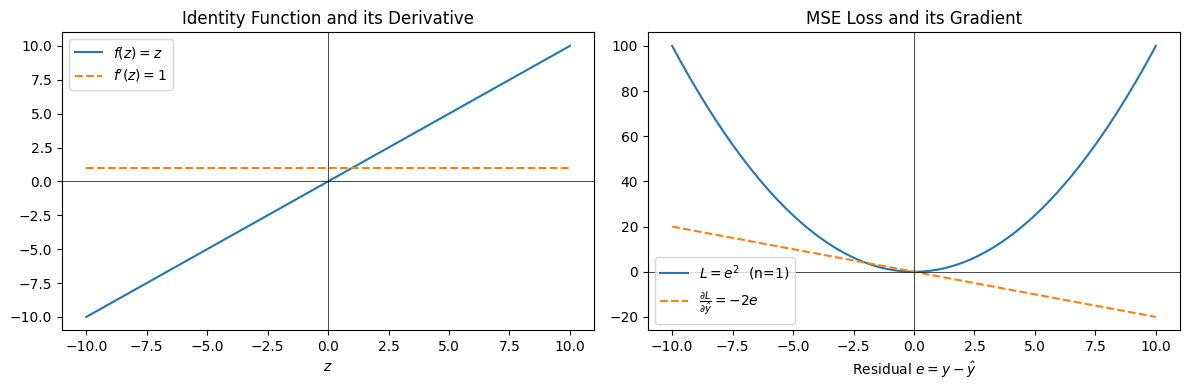

In [2]:
# plot of the identity function and its derivative
# plot of the MSE loss function and its derivative

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

z = np.linspace(-10, 10, 100)
axs[0].plot(z, z, label='$f(z) = z$')
axs[0].plot(z, np.ones_like(z), label="$f'(z) = 1$", linestyle='--')
axs[0].set_title('Identity Function and its Derivative')
axs[0].set_xlabel('$z$')
axs[0].axhline(0, color='k', lw=0.5)
axs[0].axvline(0, color='k', lw=0.5)
axs[0].legend()

e = np.linspace(-10, 10, 100)   # e = y - y_hat (residual)
axs[1].plot(e, e**2,  label='$L = e^2$  (n=1)')
axs[1].plot(e, -2*e,  label="$\\frac{\\partial L}{\\partial \\hat{y}} = -2e$", linestyle='--')
axs[1].set_title('MSE Loss and its Gradient')
axs[1].set_xlabel('Residual $e = y - \\hat{y}$')
axs[1].axhline(0, color='k', lw=0.5)
axs[1].axvline(0, color='k', lw=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()

# Binary Classification

For this type of problem our output variable can take only two possible values, in detail:

- Given input ($n \times d$)-dimensional features $x_i \in \mathbb{R}^{d}$ with $i = 1, \dots, n$
- To each of them we associate a target variable $y_i \in \{0,1\}$ or $y_i \in \{-1,+1\}$

In this case, we need to have an output that mirrors the domain of the target variable. Usually we want an activation function that is bounded to the same domain, so that we can threshold and get a discrete output. Whether a function should be "squashed" between 0 and 1 depends entirely on what that specific layer of the neural network is trying to achieve. We typically restrict the output to the $(0, 1)$ range only in the **output layer** for specific tasks. The possible activation functions we can use are:


## Sigmoid Activation Function $\sigma : \mathbb{R} \to (0,1)$

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

- It takes any real value as input and outputs values in the range $(0, 1)$. The larger the input 
  (more positive), the closer the output will be to 1, whereas the smaller the input (more 
  negative), the closer the output will be to 0
- Commonly used when we want to predict a **probability** as output
- Differentiable everywhere and provides a smooth gradient
- The derivative $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ has a **maximum of 0.25 at $z=0$** — 
  this small maximum is exactly what causes the vanishing gradient problem in deep networks, as 
  repeated multiplication of values $< 0.25$ shrinks the gradient exponentially as it 
  backpropagates through layers


### Relation with Logistic Regression
- If we train an Adaline model with a sigmoid activation function at the output and minimize 
  binary cross-entropy, we obtain exactly **logistic regression** with parameters trained via 
  (stochastic) gradient descent
- Logistic regression can be seen as a 
  single neuron with a sigmoid output and a log-loss objective


## Hyperbolic Tangent $\tanh : \mathbb{R} \to (-1, +1)$

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}, \qquad \tanh'(z) = 1 - \tanh^2(z)$$

- The larger the input (more positive), the closer the output will be to $+1$, whereas the 
  smaller the input (more negative), the closer the output will be to $-1$, as the domain of 
  the function is in the $(-1, +1)$ range
- The output of the tanh activation is **zero-centered**, we can easily map output values as 
  strongly negative, neutral, or strongly positive
- The derivative $\tanh'(z) = 1 - \tanh^2(z)$ has a **maximum of 1 at $z=0$** and approaches 
  0 as $|z| \to \infty$, it faces the same vanishing gradient problem as sigmoid, but is 
  strictly better due to the larger gradient range and zero-centered outputs
- For binary classification with labels $y \in \{-1, +1\}$, tanh is a natural output activation 
  since its range matches the label domain exactly


## Softplus $: \mathbb{R} \to (0, +\infty)$

$$f(z) = \log(1 + e^z), \qquad f'(z) = \sigma(z) = \frac{1}{1+e^{-z}}$$

- Smooth approximation of the ReLU function (ramp function) — it behaves like $z$ for large 
  positive inputs and like 0 for large negative inputs, but is differentiable everywhere 
  including at $z = 0$
- Note that its derivative **is exactly the sigmoid function** — a useful mathematical identity
- Less commonly used as an output activation for binary classification since its output is 
  unbounded above; more relevant as a hidden layer activation when you need a smooth, 
  always-positive nonlinearity


## Loss Functions

As we are dealing with a binary problem, the most used loss functions are:

### Binary Cross-Entropy (Log-Loss)
**Entropy is the expected value of the surprise** -> the entropy of a random variable is the average level of information (also surprise, or uncertainty) inherent to the variable’s possible outcomes
>  *If a highly likely event occurs, the message carries very little information. On the other hand, if a highly unlikely event occurs, the message is much more informative.*

We want to maximize the log-likelihood of 
the correct label under the predicted probability:


$$L = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i)\log(1 - \hat{p}_i) \right]$$

$$\frac{\partial L}{\partial \hat{p}_i} = -\frac{y_i}{\hat{p}_i} + \frac{1 - y_i}{1 - \hat{p}_i}$$

- If combined with the sigmoid, the gradient simplifies to $\hat{p}_i - y_i$ — 
  the prediction error. This clean form is why sigmoid + BCE is the default pairing

### Hinge Loss (for $y \in \{-1, +1\}$ labels)

$$L = \frac{1}{n}\sum_{i=1}^{n} \max\{1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b),\ 0\}$$

- Penalizes not just misclassifications, but also correct predictions that fall within the 
  margin of $1$ -> this is the loss that leads to the **Support Vector Machine (SVM)**
- **Pros:** Focuses entirely on boundary geometry; maximizes margin; outlier-robust
- **Cons:** Does not output probabilities; non-differentiable at $y_i(\mathbf{w}^\top \mathbf{x}_i + b) = 1$

### KL Divergence
We are comparing two probability distributions (*true distribution vs predicted probability*) -> the difference between the distributions can be quantfied by estimating their statistical distance

When we frame binary classification as matching two distributions $P$ (true) and $Q$ (predicted):

$$D_{KL}(P \| Q) = \sum_i P(i) \log \frac{P(i)}{Q(i)}, \qquad \frac{\partial D_{KL}}{\partial Q(i)} = -\frac{P(i)}{Q(i)}$$

- This is basically the difference (distance) between two different probability distributions
  - This is why the outputs do not need to be one hot encoded rather $P$ can be any probability distribution 
    - it treats the target as a distribution, not a point. Note that when 
P
P is one-hot, KL divergence reduces exactly to cross-entropy up to a constant (the entropy of 
P
P, which is 0 for one-hot)
- The intuition for the KL divergence score is that when the probability for an event from P is large, but the probability for the same event in Q is small, there is a large divergence
  - When the probability from P is small and the probability from Q is large, there is also a large divergence, but not as large as the first case
  - **When the score is 0, it suggests that both distributions are identical otherwise the score is positive**
- **Pros:** Generalizes naturally to distributions; used in variational inference and generative models
- **Cons:** Asymmetric ($D_{KL}(P\|Q) \neq D_{KL}(Q\|P)$); undefined when $Q(i) = 0$


## Architectures
- **Perceptron** single neuron, step function output, trained with mistake-driven updates
- **Adaline** + Sigmoid — single neuron, sigmoid output, trained with BCE and gradient descent → logistic regression
- **MLP** multiple hidden layers with ReLU/tanh activations, sigmoid at output neuron


## Notes

**When to avoid the range $(0,1)$ in hidden layers.** In deep networks, due to the vanishing 
gradient problem, we often avoid activations that compress values between 0 and 1 in hidden layers. 
The repeated multiplication of gradient values $< 1$ during backpropagation causes the signal to 
shrink exponentially as it reaches earlier layers
- To fix this, we use activations such as **ReLU** ($f(z) = \max(0, z)$) which cover a much larger 
range. It outputs $0$ for negative inputs but any positive value for positive inputs

This is why sigmoid and tanh are used **almost exclusively at the output layer** for output range 
transformation, not in the hidden layers of deep networks

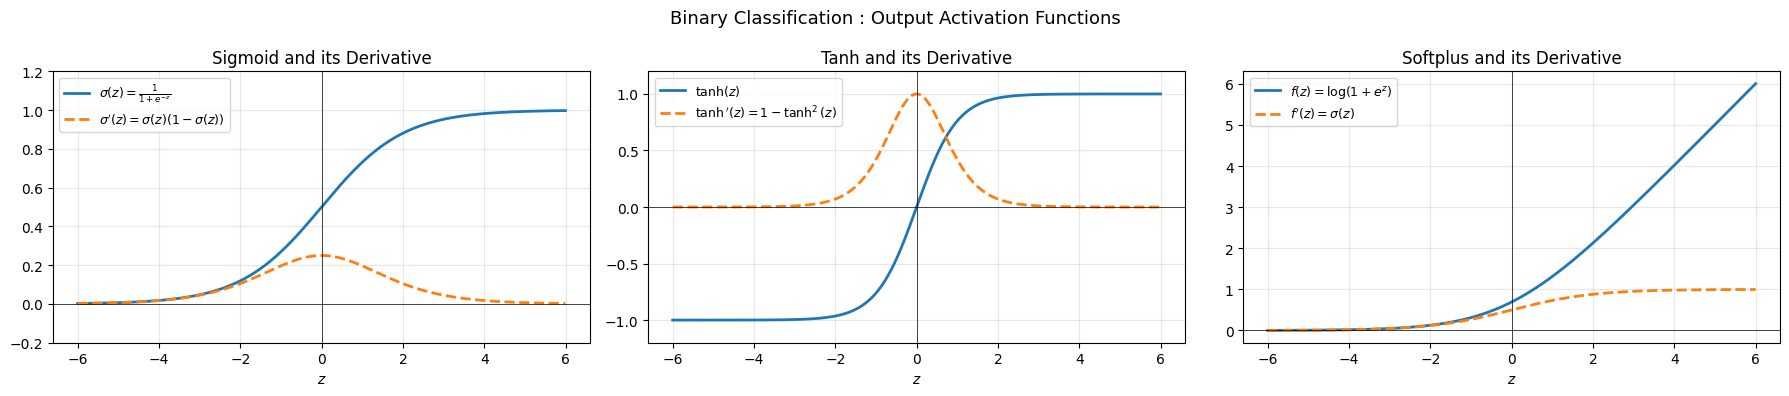

In [3]:
z = np.linspace(-6, 6, 300)

sigmoid   = 1 / (1 + np.exp(-z))
d_sigmoid = sigmoid * (1 - sigmoid)

tanh      = np.tanh(z)
d_tanh    = 1 - np.tanh(z)**2

softplus  = np.log(1 + np.exp(z))
d_softplus = sigmoid

ig, axs = plt.subplots(1, 3, figsize=(18, 4))

configs = [
    (sigmoid, d_sigmoid, r'$\sigma(z) = \frac{1}{1+e^{-z}}$', r"$\sigma'(z) = \sigma(z)(1-\sigma(z))$", 'Sigmoid',(0,1)),
    (tanh, d_tanh, r'$\tanh(z)$', r"$\tanh'(z) = 1 - \tanh^2(z)$", 'Tanh', (-1, 1)),
    (softplus, d_softplus, r'$f(z) = \log(1 + e^z)$', r"$f'(z) = \sigma(z)$", 'Softplus',  None),
]

for ax, (f, df, label_f, label_df, title, ylim) in zip(axs, configs):
    ax.plot(z,f,lw=2,label=label_f)
    ax.plot(z, df,lw=2, linestyle='--',label=label_df)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(f'{title} and its Derivative', fontsize=12)
    ax.set_xlabel('$z$')
    if ylim:
        ax.set_ylim(ylim[0] - 0.2, ylim[1] + 0.2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Binary Classification : Output Activation Functions', fontsize=13)
plt.tight_layout()
plt.show()

# Multiclass Classification

For this kind of problem we could adopt some generalizations from the binary case. In this case, the output target can take $k$ **distinct** values (usually called classes or modalities), in detail:

- Given input ($n \times d$)-dimensional features $x_i \in \mathbb{R}^{d}$ with $i = 1, \dots, n$
- To each of them we associate a target variable $y_i \in \{1, \dots, k\}$, where $k$ is the number of classes

There are many ways we can deal with these problems. In the multiclass case we need to know the **nature of the classes**:
- If they have an **inherent order** then we can encode the labels with numerical values that represent their hierarchy (e.g. different severity levels, temperatures, ordered states). In this case we could use an activation function that mirrors the domain of the output target variable and apply multiple thresholding => for example, one could imagine extending the domain of the sigmoid activation function
- But usually these classes do **not have an inherent order** and we want to avoid the model creating non-existing levels. We therefore **one-hot encode** the output target, obtaining $k$ different binary vectors (one for each class), with the only non-zero vector being the one of the observation's class:$$y_i = [0, \dots, 0, \underbrace{1}_{k\text{-th position}}, 0, \dots, 0] \in \{0,1\}^k$$ => In this case the activation function is the **Softmax function**


## Softmax Function $\to$ Probability Distribution over $k$ Classes

$$\sigma(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}, \qquad k = 1, \dots, K$$

The Softmax function is a generalization of the Sigmoid function that squashes each activation between 0 and 1, with the additional constraint that **all activations sum to 1**. The output of the Softmax function is a joint probability distribution over the $K$ classes:

- Takes the raw, unbounded scores (called **logits**) produced by a neural network and transforms them into a well-defined probability distribution, making it possible to interpret each output as the likelihood of a specific class
- The exponential $e^{z_k}$ in the numerator ensures all outputs are positive, and the normalization by the sum ensures they sum to 1 => no matter how large or small the logits are
- **Numerical instability:** for very large $z_k$, $e^{z_k}$ can overflow. In practice we use the numerically stable version by subtracting the maximum logit before exponentiating:
$$\sigma(\mathbf{z})_k = \frac{e^{z_k - \max_j z_j}}{\sum_{j=1}^{K} e^{z_j - \max_j z_j}}$$
  This does not change the output (the constant cancels) but prevents overflow

### Derivative (Jacobian)

Unlike sigmoid and tanh, the derivative of softmax is not a scalar as since the input and output are both vectors, the derivative is a **Jacobian matrix**:

$$\frac{\partial \sigma_k}{\partial z_j} = \sigma_k (\delta_{kj} - \sigma_j) = 
\begin{cases} \sigma_k(1 - \sigma_k) & \text{if } k = j \\ -\sigma_k \sigma_j & \text{if } k \neq j \end{cases}$$

where $\delta_{kj}$ is the Kronecker delta. In practice, this is never computed explicitly as when combined with cross-entropy loss, the combined gradient simplifies beautifully to $\hat{p}_k - y_k$ (the prediction error), just like sigmoid + BCE in the binary case

## Loss Functions

### Categorical Cross-Entropy

The natural companion to softmax, it measures how far the predicted probability distribution is from the true one-hot distribution:

$$L = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{i,k} \log \hat{p}_{i,k}$$

Since $y_{i,k}$ is one-hot (only one term is non-zero), this simplifies for a single sample to:

$$L_i = -\log \hat{p}_{i, c_i}$$

where $c_i$ is the true class of sample $i$. Tthe loss is simply the **negative log probability assigned to the correct class**. All other classes vanish from 
the sum entirely

- Combined gradient with softmax: $\frac{\partial L}{\partial z_k} = \hat{p}_k - y_k$, the same clean form as sigmoid + BCE

### KL Divergence

As in the binary case, when the target is **not** one-hot (e.g. soft labels, label smoothing, knowledge distillation), we use KL divergence instead:

$$D_{KL}(P \| Q) = \sum_{k=1}^{K} P(k) \log \frac{P(k)}{Q(k)}$$

## Architectures

An important architectural constraint: the **output layer must have exactly $K$ neurons**, one per class, so that the softmax can produce a probability vector of length $K$:

$$\mathbf{z} = \mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + \mathbf{b}^{(L)} \in \mathbb{R}^K 
\xrightarrow{\text{softmax}} \hat{\mathbf{p}} \in (0,1)^K, \quad \sum_k \hat{p}_k = 1$$

- **Perceptron / single layer** : $K$ output neurons, softmax activation, no hidden layers => this is equivalent to **multinomial logistic regression**
- **MLP** : multiple hidden layers with ReLU activations, $K$ output neurons with softmax
- **CNN** (Image Classification) : convolutional + pooling layers for feature extraction, followed by fully connected layers, $K$ output neurons with softmax

In [ ]:
# showcase of the softmax activation layer for multi-class classification for k=4 classes
np.random.seed(42) # answer to everything
x = np.random.randn(1, 10) # a random input vector with 10 features (d=10)

# Dense output layer: 4 neurons (one per class) + softmax activation
# This is W^(L) h + b followed by softmax
output_layer = tf.keras.layers.Dense(4, activation='softmax')
probabilities = output_layer(x).numpy()

print("Output probabilities for each class:")
for i, prob in enumerate(probabilities[0]):
    print(f"Class {i}: {prob:.4f}")

print("\nSum of probabilities:", np.sum(probabilities[0]))


Output probabilities for each class:
Class 0: 0.3922
Class 1: 0.2278
Class 2: 0.2947
Class 3: 0.0853

Sum of probabilities: 1.0


# [Multiclass Classification — The Image Case](#Multiclass-Classification-The-Image-Case)

For images, the **architectural design** of the network changes the most, while the activation principles for the output layer remain identical to the numerical multiclass case. For images though, it is useful to keep in mind a few things

- An image is a function $I(x,y)$ such that $I : (x,y) \rightarrow [0, 255]$ (grayscale) or $[0, 255]^3$ (RGB), where each pixel at position $(x,y)$ carries a gray-level or channel color intensity
- If the problem is classification, our input tensor will be $x \in \mathbb{R}^{n \times h \times w \times c}$ where:
  - $n$ = number of images in the dataset
  - $h$ = height of the image in pixels
  - $w$ = width of the image in pixels
  - $c$ = number of channels ($c=1$ grayscale, $c=3$ for RGB)
- The output target is $y \in \{0,1\}^{n \times k}$ one-hot encoded, where $k$ is the number of classes

**Note:** A simple but naive approach would be to flatten the image into a 1D vector $\mathbf{x} \in \mathbb{R}^{h \times w \times c}$ and feed it into an MLP, but it's not really feasable we have large images as flattening them will produce vectors of thousands of entries, they also ignore the position and structure of images. Solution => **convolutional neural networks**


## Convolutional Neural Networks (CNNs)

Our aim is to find the right **kernels** that can be applied to the images in order to extract useful patterns for classification. We do this using Convolutional Neural Networks.

Their structure consists of a series of **convolutional layers** that (as the name implies) convolve the input image with a set of **learned** filters/kernels in order to extract useful information (such as edges, corners, textures, shapes). Formally, the convolution operation at position $(i, j)$ for a single filter $\mathbf{K}$ is:

$$(\mathbf{I} * \mathbf{K})(i, j) = \sum_{m}\sum_{n} \mathbf{I}(i+m,\ j+n) \cdot \mathbf{K}(m, n)$$

- The filter $\mathbf{K}$ slides across the full spatial extent of the input, computing a **dot product** at each position → producing a 2D **feature map** (also called activation map)
  - Actually this is not convolution but cross-correlation (https://www.geeksforgeeks.org/machine-learning/convolution-and-cross-correlation-in-cnn/ **the kernel it's not flipped!!**)
- Each convolutional layer learns $F$ different filters, producing $F$ feature maps stacked along the channel dimension
  - each filter specializes in detecting a different visual pattern
- The same filter is applied across the entire image
  - A $3\times3$ filter has only 9 learnable parameters regardless of the image size


## ReLU Families in Convolutional Layers

After each convolution we apply a **non-linear activation function** to the feature map. The most used activations are from the **ReLU family** (ReLU, Leaky ReLU, ELU, GELU, Softplus)

- ReLU outputs $\max(0, z)$, which has a gradient of exactly 1 for all $z > 0$. In a deep CNN with many convolutional layers, sigmoid and tanh would saturate and kill the gradient long before it reaches the early layers as the shrink the outputs in a specified range
-ReLU sets all negative activations to zero. In a feature map this means most neurons are inactive for a given image, only the filters that detected their target pattern fire
- ReLU though has the **dying ReLU problem**, if a neuron's pre-activation is always negative, it outputs 0 forever and its gradient is always 0, meaning it never updates. This is why variants exist:
  - **Leaky ReLU** : $\max(\alpha z, z),\ \alpha \ll 1$ | Small gradient for $z < 0$ => neuron never fully dies
  - **ELU** : $z$ if $z>0$, else $\alpha(e^z-1)$ | Smooth negative region, zero-centered mean activations (like tanh)
  - **GELU** : $z \cdot \Phi(z)$ | Probabilistic soft gating => used in Transformers
  - **Softplus** : $\log(1 + e^z)$ | Smooth ReLU approximation, differentiable at 0


## Pooling Layers

After convolution + activation, **pooling layers** progressively reduce the spatial dimensions 
of the feature maps:

$$\text{MaxPool}(i,j) = \max_{(m,n) \in \mathcal{N}(i,j)} \mathbf{F}(m, n)$$

- **Spatial dimension reduction** → reduces the number of parameters in subsequent layers and controls overfitting
- **Translation invariance** → a small shift of the object in the image does not change the pooled output significantly
- After enough convolutional + pooling stages, the spatial dimensions $h \times w$ are reduced small enough to be **flattened** into a 1D vector

After the feature maps are flattened => converting the 3D tensor $(h' \times w' \times F)$ into a 1D vector $\mathbf{z} \in \mathbb{R}^{h' \cdot w' \cdot F}$. From this point onwards, the problem is **identical to the numerical multiclass case**:

$$\mathbf{z} \xrightarrow{\text{Flatten}} \mathbf{z}_{1D} \xrightarrow{\text{Dense (ReLU)}} \mathbf{h} \xrightarrow{\text{Dense}(K) + \text{Softmax}} \hat{\mathbf{p}} \in (0,1)^K$$

- The output layer has exactly $K$ neurons with softmax activation
- The loss is **categorical cross-entropy**, identical to the numerical multiclass case


## Architectures
- **LeNet-5** (1998) : First practical CNN; small conv filters; average pooling
- **AlexNet** (2012) : Deep CNN; ReLU replaces tanh; dropout regularization
- **VGGNet** (2014) : Very deep with small $3\times3$ filters stacked (same size filters)
- **ResNet** (2015) : Skip connections → gradients bypass layers → very deep training possible

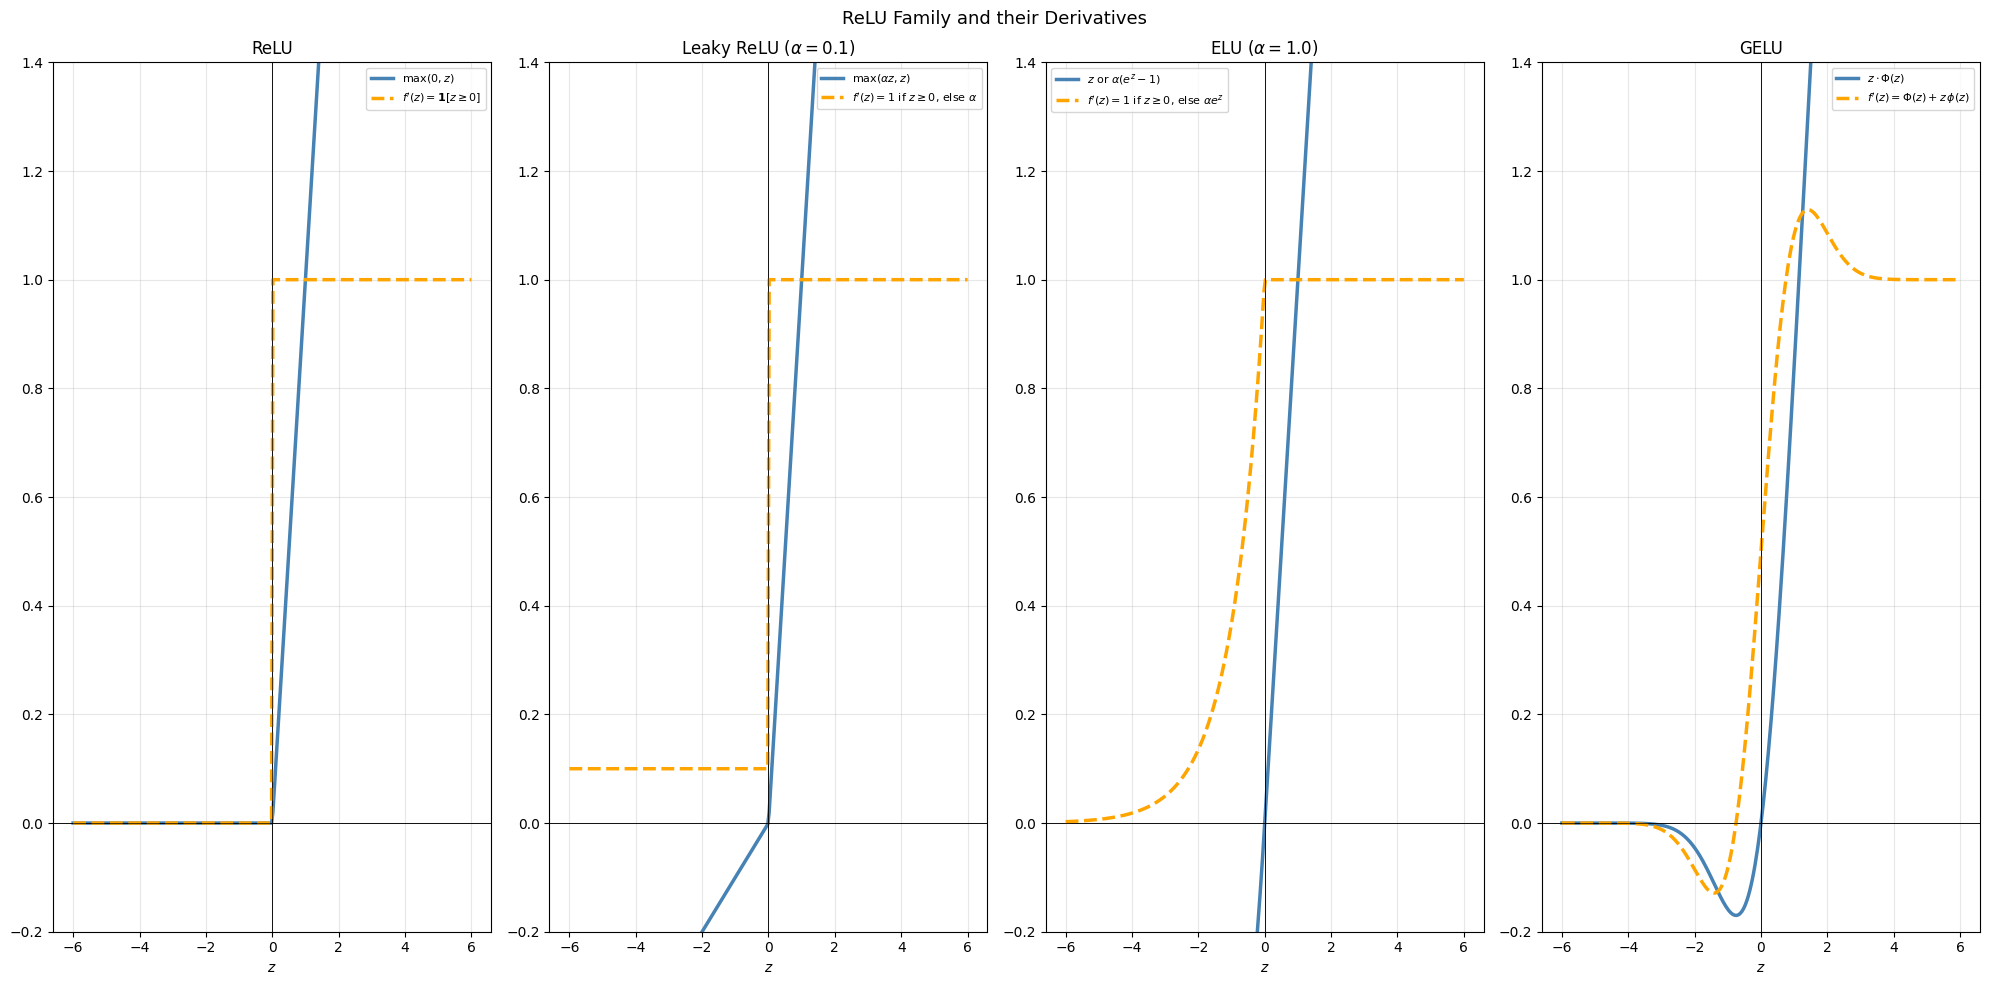

In [31]:
z = np.linspace(-6, 6, 300)

alpha_leaky = 0.1 
alpha_elu   = 1.0   

relu = np.maximum(0, z)
leaky_relu  = np.where(z >= 0, z, alpha_leaky * z)
elu = np.where(z >= 0, z, alpha_elu * (np.exp(z) - 1))
gelu = z * norm.cdf(z)   # z * Phi(z)

d_relu = np.where(z >= 0, 1, 0)
d_leaky_relu = np.where(z >= 0, 1, alpha_leaky)
d_elu = np.where(z >= 0, 1, alpha_elu * np.exp(z)) 
d_gelu = norm.cdf(z) + z * norm.pdf(z)                


configs = [
    (relu, d_relu,'ReLU',r'$\max(0, z)$', r"$f'(z) = \mathbf{1}[z \geq 0]$"),
    (leaky_relu, d_leaky_relu, f'Leaky ReLU ($\\alpha={alpha_leaky}$)', r'$\max(\alpha z, z)$', r"$f'(z) = 1$ if $z \geq 0$, else $\alpha$"),
    (elu, d_elu, f'ELU ($\\alpha={alpha_elu}$)', r'$z$ or $\alpha(e^z - 1)$',  r"$f'(z) = 1$ if $z \geq 0$, else $\alpha e^z$"),
    (gelu, d_gelu, 'GELU', r'$z \cdot \Phi(z)$', r"$f'(z) = \Phi(z) + z\,\phi(z)$"),
]

fig, axs = plt.subplots(1, 4, figsize=(20, 10))

for i, (f, df, title, label_f, label_df) in enumerate(configs):
    # top row: activation
    axs[i].plot(z, f,  lw=2.5, color='steelblue', label=label_f)
    axs[i].axhline(0, color='k', lw=0.5)
    axs[i].axvline(0, color='k', lw=0.5)
    axs[i].set_title(title, fontsize=12)
    axs[i].set_xlabel('$z$')
    axs[i].set_ylim(-2.5, 4)
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.3)

    # bottom row: derivative
    axs[i].plot(z, df, lw=2.5, color='orange', linestyle='--', label=label_df)
    axs[i].axhline(0, color='k', lw=0.5)
    axs[i].axvline(0, color='k', lw=0.5)
    axs[i].set_xlabel('$z$')
    axs[i].set_ylim(-0.2, 1.4)
    axs[i].legend(fontsize=8)
    axs[i].grid(True, alpha=0.3)

plt.suptitle('ReLU Family and their Derivatives',
             fontsize=13)
plt.tight_layout()
plt.show()

# Segmentation of Images

In this case we have the problem in whihch we want to find the distinct objects inside one image, in this case the problem is framed as:

- 

# Sequence Classification

